# Recherche des meilleurs hyperparamètres BERTopic

Ce notebook compare plusieurs configurations BERTopic, les classe selon plusieurs métriques, puis vérifie la stabilité des meilleures configurations.

In [3]:
import gc
import time
import warnings
from itertools import combinations
from pathlib import Path #pour la gestion des chemins de fichiers
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import ParameterGrid
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.feature_extraction.text import CountVectorizer

from umap import UMAP
from hdbscan import HDBSCAN
from hdbscan.validity import validity_index

from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from sentence_transformers import SentenceTransformer #pour les embeddings de phrase

from gensim.corpora import Dictionary
from gensim.models import CoherenceModel


warnings.filterwarnings("ignore")


In [4]:
# Racine du projet ZOLA-DTM
PROJECT_ROOT = Path.cwd().parent

# Dossiers principaux
DATA_DIR = PROJECT_ROOT / "data"
DONNEES_ANNEX_DIR = DATA_DIR / "donnees_annex"
CACHE_DIR = DONNEES_ANNEX_DIR / "data_cache"

# Fichier des embeddings
CHEMIN_EMBEDDINGS = CACHE_DIR / "embeddings_sentence_camembert.npy"

print("Répertoire courant :", Path.cwd())
print("Racine projet       :", PROJECT_ROOT)
print("Dossier data        :", DATA_DIR)
print("Dossier cache       :", CACHE_DIR)
print("Embeddings          :", CHEMIN_EMBEDDINGS)

Répertoire courant : /Users/morganr/zola-dtm/02_notebook_analyse
Racine projet       : /Users/morganr/zola-dtm
Dossier data        : /Users/morganr/zola-dtm/data
Dossier cache       : /Users/morganr/zola-dtm/data/donnees_annex/data_cache
Embeddings          : /Users/morganr/zola-dtm/data/donnees_annex/data_cache/embeddings_sentence_camembert.npy


## 1. Chargement du corpus et chargement ou calcul des embeddings

In [5]:
chemin_csv = Path("../data/2_processed/02_corpus_zola_lematise_128.csv")

print("cwd =", Path.cwd())
print("chemin_csv =", chemin_csv)
print("resolve =", chemin_csv.resolve())
print("exists =", chemin_csv.exists())

cwd = /Users/morganr/zola-dtm/02_notebook_analyse
chemin_csv = ../data/2_processed/02_corpus_zola_lematise_128.csv
resolve = /Users/morganr/zola-dtm/data/2_processed/02_corpus_zola_lematise_128.csv
exists = True


In [6]:
COL_TEXTE = "phrases_lemm"
COL_ROMAN = "roman"

RANDOM_STATE = 42

# Calculer DBCV peut ralentir légèrement la grille.
CALCULER_DBCV = True

# Nombre maximal de documents utilisés pour la silhouette.
TAILLE_ECHANTILLON_SILHOUETTE = 4000


df=pd.read_csv(Path(chemin_csv, encoding="utf-8"))


CHEMIN_EMBEDDINGS = Path("../data/donnees_annex/data_cache/embeddings_sentence_camembert.npy")

if CHEMIN_EMBEDDINGS.exists():
    print("Chargement des embeddings sauvegardés...")
    embeddings = np.load(CHEMIN_EMBEDDINGS, allow_pickle=False)
else:
    embedding_model = SentenceTransformer("dangvantuan/sentence-camembert-base")

    print("Génération des embeddings sémantiques...")
    embeddings = embedding_model.encode(
        df["texte"].tolist(),
        batch_size=64,
        show_progress_bar=True
    )
    CHEMIN_EMBEDDINGS.parent.mkdir(parents=True, exist_ok=True)
    np.save(CHEMIN_EMBEDDINGS, embeddings)
    print(f"Embeddings sauvegardés dans : {CHEMIN_EMBEDDINGS}")

Chargement des embeddings sauvegardés...


In [7]:
# Vérification des colonnes
assert COL_TEXTE in df.columns, (
    f"La colonne '{COL_TEXTE}' n'existe pas dans df.")
assert COL_ROMAN in df.columns, (
    f"La colonne '{COL_ROMAN}' n'existe pas dans df.")

# Conversion des embeddings
embeddings_array_initial = np.asarray(embeddings)

assert len(df) == len(embeddings_array_initial), (
    "Le nombre de lignes de df ne correspond pas "
    "au nombre d'embeddings.")

# Masque des documents non vides
masque_documents = (df[COL_TEXTE].notna() & df[COL_TEXTE].astype(str).str.strip().ne(""))

# DataFrame utilisé par BERTopic
df_model = (df.loc[masque_documents].copy().reset_index(drop=True))

# Documents
documents = (df_model[COL_TEXTE].astype(str).tolist())

# Romans associés aux documents
romans = (df_model[COL_ROMAN].astype(str).tolist())

# Embeddings alignés
embeddings_array = embeddings_array_initial[masque_documents.to_numpy()]

# Tokenisation simple pour la cohérence C_v
texts_tokenises = [
    document.split()
    for document in documents
]

# Dictionnaire Gensim
dictionary = Dictionary(texts_tokenises)


print("Nombre de documents :", len(documents))
print("Nombre de romans :", df_model[COL_ROMAN].nunique())
print("Dimensions des embeddings :", embeddings_array.shape)
print("Taille du dictionnaire :", len(dictionary))

Nombre de documents : 61432
Nombre de romans : 31
Dimensions des embeddings : (61432, 768)
Taille du dictionnaire : 23302


## 2. Fonctions d'évaluation

Ces fonctions calculent la cohérence, la diversité lexicale, la silhouette, le DBCV et les statistiques de couverture des topics.

In [8]:
def extraire_mots_topics(
    topic_model,
    labels,
    top_n_words=10,
    dictionary=None
):
    """
    Extrait les mots des topics, en excluant le topic -1.

    Si un dictionnaire Gensim est fourni, seuls les mots présents
    dans ce dictionnaire sont conservés.
    """

    labels = np.asarray(labels)

    topic_ids = sorted(
        int(topic_id)
        for topic_id in np.unique(labels)
        if topic_id != -1
    )

    topics_words = []

    for topic_id in topic_ids:

        representation = topic_model.get_topic(topic_id)

        if not representation:
            continue

        words = [
            word
            for word, _ in representation[:top_n_words]
        ]

        if dictionary is not None:
            words = [
                word
                for word in words
                if word in dictionary.token2id
            ]

        # Éviter les topics insuffisamment représentés
        if len(words) >= 2:
            topics_words.append(words)

    return topics_words

def calculer_coherence_cv(
    topic_model,
    labels,
    texts_tokenises,
    dictionary,
    top_n_words=10
):
    """
    Calcule la cohérence C_v des topics BERTopic.
    """

    topics_words = extraire_mots_topics(
        topic_model=topic_model,
        labels=labels,
        top_n_words=top_n_words,
        dictionary=dictionary
    )

    if len(topics_words) < 2:
        return np.nan

    try:
        coherence_model = CoherenceModel(
            topics=topics_words,
            texts=texts_tokenises,
            dictionary=dictionary,
            coherence="c_v",
            topn=top_n_words,
            processes=1
        )

        return float(coherence_model.get_coherence())

    except Exception:
        return np.nan
    
def calculer_diversite_topics(
    topic_model,
    labels,
    top_n_words=10
):
    """
    Diversité lexicale :
    nombre de termes uniques / nombre total de termes.
    """

    topics_words = extraire_mots_topics(
        topic_model=topic_model,
        labels=labels,
        top_n_words=top_n_words,
        dictionary=None
    )

    tous_les_mots = [
        word
        for topic_words in topics_words
        for word in topic_words
    ]

    if not tous_les_mots:
        return np.nan

    return len(set(tous_les_mots)) / len(tous_les_mots)    
    
def evaluer_modele(
    topic_model,
    topics,
    texts_tokenises,
    dictionary,
    silhouette_sample_size=2000,
    calculer_dbcv=True
):
    """
    Évalue un modèle BERTopic sur les topics bruts produits
    par HDBSCAN, avant toute réduction des outliers.
    """

    labels = np.asarray(topics, dtype=int)

    # Coordonnées UMAP utilisées par HDBSCAN
    embeddings_umap = np.asarray(
        topic_model.umap_model.embedding_,
        dtype=np.float64
    )

    masque_valides = labels != -1

    labels_valides = labels[masque_valides]
    embeddings_valides = embeddings_umap[masque_valides]

    topic_ids = np.unique(labels_valides)
    nombre_topics = len(topic_ids)

    nombre_documents = len(labels)
    nombre_assignes = int(masque_valides.sum())

    taux_outliers = float(np.mean(labels == -1))
    couverture = 1 - taux_outliers

    # --------------------------------------------------------------
    # Tailles des topics
    # --------------------------------------------------------------

    if nombre_topics > 0:

        tailles_topics = (
            pd.Series(labels_valides).value_counts())

        taille_min = int(tailles_topics.min())
        taille_mediane = float(tailles_topics.median())
        taille_max = int(tailles_topics.max())

        largest_topic_share = (
            taille_max / nombre_assignes
            if nombre_assignes > 0
            else np.nan
        )

    else:

        taille_min = np.nan
        taille_mediane = np.nan
        taille_max = np.nan
        largest_topic_share = np.nan

    # --------------------------------------------------------------
    # Silhouette dans l'espace UMAP
    # --------------------------------------------------------------

    silhouette = np.nan

    condition_silhouette = (
        nombre_topics >= 2
        and nombre_assignes > nombre_topics
    )

    if condition_silhouette:

        try:

            if nombre_assignes > silhouette_sample_size:

                silhouette = silhouette_score(
                    embeddings_valides,
                    labels_valides,
                    metric="euclidean",
                    sample_size=silhouette_sample_size,
                    random_state=RANDOM_STATE
                )

            else:

                silhouette = silhouette_score(
                    embeddings_valides,
                    labels_valides,
                    metric="euclidean"
                )

        except Exception:
            silhouette = np.nan

    # --------------------------------------------------------------
    # DBCV
    # --------------------------------------------------------------

    dbcv = np.nan

    if calculer_dbcv and nombre_topics >= 2:

        try:
            dbcv = validity_index(
                embeddings_umap,
                labels,
                metric="euclidean"
            )

            dbcv = float(dbcv)

        except Exception:
            dbcv = np.nan

    # --------------------------------------------------------------
    # Cohérence et diversité
    # --------------------------------------------------------------

    coherence_cv = calculer_coherence_cv(
        topic_model=topic_model,
        labels=labels,
        texts_tokenises=texts_tokenises,
        dictionary=dictionary,
        top_n_words=10
    )

    topic_diversity = calculer_diversite_topics(
        topic_model=topic_model,
        labels=labels,
        top_n_words=10
    )

    return {
        "n_documents": nombre_documents,
        "n_assigned": nombre_assignes,
        "n_topics": nombre_topics,
        "outlier_rate": taux_outliers,
        "coverage": couverture,
        "silhouette_umap": silhouette,
        "dbcv": dbcv,
        "coherence_cv": coherence_cv,
        "topic_diversity": topic_diversity,
        "min_topic_size_observed": taille_min,
        "median_topic_size": taille_mediane,
        "max_topic_size_observed": taille_max,
        "largest_topic_share": largest_topic_share
        }

## 3. Définition et exécution de la grille de recherche

In [10]:
n_documents = len(documents)

proportions = [0.002, 0.003, 0.004, 0.005]

min_cluster_sizes = [
    round(n_documents * proportion)
    for proportion in proportions
]

print(min_cluster_sizes)
# Environ : [123, 184, 246, 307]

[123, 184, 246, 307]


In [11]:
param_grid = {
    "n_neighbors": [25, 50, 75],
    "n_components": [10, 20, 30],
    "min_cluster_size": [123, 184, 246, 307],
    "min_samples": [1, 3, 5, 10]
}

configurations = list(ParameterGrid(param_grid))

print("Nombre de configurations à tester :",len(configurations))

Nombre de configurations à tester : 144


In [ ]:
resultats = []

for numero, params in enumerate(configurations, start=1):

    print(
        f"\n{'=' * 70}\n"
        f"Configuration {numero}/{len(configurations)}\n"
        f"{params}"
    )

    debut = time.perf_counter()

    topic_model_test = None

    try:

        # ----------------------------------------------------------
        # UMAP
        # ----------------------------------------------------------
        umap_model = UMAP(
            n_neighbors=params["n_neighbors"],
            n_components=params["n_components"],
            min_dist=0.0,
            metric="cosine",
            random_state=RANDOM_STATE,
            low_memory=True)
        # ----------------------------------------------------------
        # HDBSCAN
        # ----------------------------------------------------------
        hdbscan_model = HDBSCAN(
            min_cluster_size=params["min_cluster_size"],
            min_samples=params["min_samples"],
            metric="euclidean",
            cluster_selection_method="eom",
            prediction_data=False,
            core_dist_n_jobs=-1)
        # ----------------------------------------------------------
        # Représentation lexicale
        # ----------------------------------------------------------
        vectorizer_model = CountVectorizer(
            min_df=2,
            max_df=0.8,
            ngram_range=(1, 1))

        ctfidf_model = ClassTfidfTransformer(
            reduce_frequent_words=True,
            bm25_weighting=True)
        # ----------------------------------------------------------
        # BERTopic
        # ----------------------------------------------------------
        topic_model_test = BERTopic(
            language="french",
            hdbscan_model=hdbscan_model,
            umap_model=umap_model,
            vectorizer_model=vectorizer_model,
            ctfidf_model=ctfidf_model,
            calculate_probabilities=False,
            nr_topics=None,
            verbose=False)

        topics_test, _ = topic_model_test.fit_transform(
            documents,
            embeddings=embeddings_array)
        # ----------------------------------------------------------
        # Évaluation
        # ----------------------------------------------------------
        metriques = evaluer_modele(
            topic_model=topic_model_test,
            topics=topics_test,
            texts_tokenises=texts_tokenises,
            dictionary=dictionary,
            silhouette_sample_size=TAILLE_ECHANTILLON_SILHOUETTE,
            calculer_dbcv=CALCULER_DBCV
        )
        duree = time.perf_counter() - debut

        ligne = {
            **params,
            **metriques,
            "duration_seconds": duree,
            "status": "ok",
            "error": None
        }

        print(
            f"Topics       : {metriques['n_topics']}\n"
            f"Outliers     : {metriques['outlier_rate']:.1%}\n"
            f"Silhouette   : {metriques['silhouette_umap']:.3f}\n"
            f"DBCV         : {metriques['dbcv']:.3f}\n"
            f"C_v          : {metriques['coherence_cv']:.3f}\n"
            f"Diversité    : {metriques['topic_diversity']:.3f}\n"
            f"Temps        : {duree:.1f} secondes"
        )

    except Exception as erreur:

        duree = time.perf_counter() - debut

        ligne = {
            **params,
            "n_documents": len(documents),
            "n_assigned": np.nan,
            "n_topics": np.nan,
            "outlier_rate": np.nan,
            "coverage": np.nan,
            "silhouette_umap": np.nan,
            "dbcv": np.nan,
            "coherence_cv": np.nan,
            "topic_diversity": np.nan,
            "min_topic_size_observed": np.nan,
            "median_topic_size": np.nan,
            "max_topic_size_observed": np.nan,
            "largest_topic_share": np.nan,
            "duration_seconds": duree,
            "status": "error",
            "error": str(erreur)
        }

        print("ERREUR :", erreur)

    resultats.append(ligne)
    
    resultats_df = pd.DataFrame(resultats)
    
    # Sauvegarde après chaque configuration
    chemin_sortie = Path("..") /"data" /"3_optimisation" /"resultats_grille_bertopic.csv"
    chemin_sortie.parent.mkdir(parents=True, exist_ok=True)
    resultats_df.to_csv(chemin_sortie, index=False, encoding="utf-8")
    

    # Nettoyage mémoire
    if topic_model_test is not None:
        del topic_model_test

    gc.collect()


Configuration 1/256
{'min_cluster_size': 20, 'min_samples': 1, 'n_components': 5, 'n_neighbors': 10}
Topics       : 255
Outliers     : 55.6%
Silhouette   : 0.246
DBCV         : -0.043
C_v          : 0.390
Diversité    : 0.906
Temps        : 50.3 secondes

Configuration 2/256
{'min_cluster_size': 20, 'min_samples': 1, 'n_components': 5, 'n_neighbors': 25}


## 4. Classement multicritère des configurations

Les configurations sont filtrées puis comparées à partir de la cohérence, de la silhouette, du DBCV, de la diversité, de la couverture et de l'équilibre entre les topics.

In [8]:
resultats_df = pd.read_csv(Path("..")/"data"/"3_optimisation"/"resultats_grille_bertopic.csv", encoding="utf-8")

resultats_valides = (resultats_df[resultats_df["status"] == "ok"].copy())

colonnes_affichage = [
    "n_neighbors",
    "n_components",
    "min_cluster_size",
    "min_samples",
    "n_topics",
    "outlier_rate",
    "silhouette_umap",
    "dbcv",
    "coherence_cv",
    "topic_diversity",
    "min_topic_size_observed",
    "median_topic_size",
    "max_topic_size_observed",
    "largest_topic_share",
    "duration_seconds"
]

display(
    resultats_valides[colonnes_affichage]
    .sort_values(
        ["coherence_cv", "silhouette_umap"],
        ascending=False
    )
    .head(20)
    .style.format({
        "outlier_rate": "{:.1%}",
        "silhouette_umap": "{:.3f}",
        "dbcv": "{:.3f}",
        "coherence_cv": "{:.3f}",
        "topic_diversity": "{:.3f}",
        "largest_topic_share": "{:.1%}",
        "duration_seconds": "{:.1f}"
    })
)

,n_neighbors,n_components,min_cluster_size,min_samples,n_topics,outlier_rate,silhouette_umap,dbcv,coherence_cv,topic_diversity,min_topic_size_observed,median_topic_size,max_topic_size_observed,largest_topic_share,duration_seconds
255,60,20,120,15,9,75.2%,0.456,0.065,0.605,0.889,130,379.000000,2964,40.7%,49.3
165,25,10,80,10,12,75.7%,0.394,0.060,0.593,0.967,80,263.500000,2674,37.5%,29.3
155,60,15,80,5,13,71.3%,0.336,-0.026,0.589,0.923,81,168.000000,2833,33.5%,54.2
173,25,20,80,10,13,71.2%,0.366,0.018,0.588,0.946,98,272.000000,3232,38.2%,33.3
191,60,20,80,15,11,76.5%,0.475,0.053,0.584,0.900,86,335.000000,2964,42.9%,57.3
181,25,10,80,15,12,71.8%,0.384,-0.011,0.576,0.950,92,313.000000,3146,38.0%,35.6
189,25,20,80,15,12,72.4%,0.396,0.034,0.576,0.917,90,254.000000,3161,39.0%,36.4
102,50,10,40,10,16,75.8%,0.316,0.016,0.573,0.925,43,158.000000,2627,36.9%,47.1
107,60,15,40,10,14,73.0%,0.376,0.011,0.569,0.914,45,277.000000,2750,34.7%,55.7
147,60,5,80,5,16,75.8%,0.394,-0.054,0.568,0.944,84,238.500000,1842,25.8%,47.1


In [28]:
candidats = (
    resultats_valides
    .dropna(
        subset=[
            "n_topics",
            "outlier_rate",
            "silhouette_umap",
            "coherence_cv",
            "topic_diversity",
            "largest_topic_share"
        ]
    )
    .copy()
)

candidats = candidats[
     #Écarter les solutions triviales
    (candidats["n_topics"] >= 10) 

    # Écarter les modèles classant presque tout en bruit
    & (candidats["outlier_rate"] <= 0.6)

    # Écarter les modèles dominés par un seul topic
    & (candidats["largest_topic_share"] <= 0.40)
].copy()

print("Nombre de configurations valides :",len(candidats))

Nombre de configurations valides : 5


In [29]:
# Plus la valeur est élevée, mieux c'est
candidats["coherence_rank"] = (candidats["coherence_cv"].rank(pct=True))


candidats["silhouette_rank"] = (candidats["silhouette_umap"].rank(pct=True))


candidats["diversity_rank"] = (candidats["topic_diversity"].rank(pct=True))


candidats["coverage_rank"] = (candidats["coverage"].rank(pct=True))


# Une faible domination par le plus gros topic est préférable
candidats["balance_rank"] = ((1 - candidats["largest_topic_share"]).rank(pct=True))


# DBCV facultatif
if (CALCULER_DBCV and candidats["dbcv"].notna().sum() > 1):

    candidats["dbcv_rank"] = (candidats["dbcv"].rank(pct=True).fillna(0.5))

else:

    # Valeur constante : aucun effet sur le classement
    candidats["dbcv_rank"] = 0.5


# Score multicritère
candidats["score_global"] = (
    0.30 * candidats["coherence_rank"]
    + 0.20 * candidats["silhouette_rank"]
    + 0.15 * candidats["dbcv_rank"]
    + 0.15 * candidats["diversity_rank"]
    + 0.10 * candidats["coverage_rank"]
    + 0.10 * candidats["balance_rank"]
)

candidats = (candidats.sort_values("score_global",ascending=False,))


display(
    candidats[
        [
            "n_neighbors",
            "n_components",
            "min_cluster_size",
            "min_samples",
            "n_topics",
            "outlier_rate",
            "silhouette_umap",
            "dbcv",
            "coherence_cv",
            "topic_diversity",
            "largest_topic_share",
            "score_global"
        ]
    ]
    .head(20)
    .style.format({
        "outlier_rate": "{:.1%}",
        "silhouette_umap": "{:.3f}",
        "dbcv": "{:.3f}",
        "coherence_cv": "{:.3f}",
        "topic_diversity": "{:.3f}",
        "largest_topic_share": "{:.1%}",
        "score_global": "{:.3f}"
    })
)

,n_neighbors,n_components,min_cluster_size,min_samples,n_topics,outlier_rate,silhouette_umap,dbcv,coherence_cv,topic_diversity,largest_topic_share,score_global
207,60,20,120,1,12,59.3%,0.298,-0.076,0.525,0.958,30.8%,0.740
4,10,10,20,1,249,57.6%,0.286,0.002,0.390,0.900,3.4%,0.620
12,10,20,20,1,252,58.9%,0.293,0.043,0.388,0.898,3.6%,0.590
8,10,15,20,1,273,56.9%,0.294,0.022,0.380,0.896,4.0%,0.530
200,10,15,120,1,27,59.2%,0.220,-0.072,0.495,0.904,30.8%,0.520


In [30]:
meilleur_par_nombre_topics = (
    candidats
    .sort_values("score_global", ascending=False)
    .groupby("n_topics", as_index=False)
    .first()
    .sort_values("n_topics")
)


colonnes_par_nombre = [
    "n_topics",
    "n_neighbors",
    "n_components",
    "min_cluster_size",
    "min_samples",
    "outlier_rate",
    "silhouette_umap",
    "dbcv",
    "coherence_cv",
    "topic_diversity",
    "largest_topic_share",
    "score_global"
]


display(
    meilleur_par_nombre_topics[
        colonnes_par_nombre
    ]
    .style.format({
        "outlier_rate": "{:.1%}",
        "silhouette_umap": "{:.3f}",
        "dbcv": "{:.3f}",
        "coherence_cv": "{:.3f}",
        "topic_diversity": "{:.3f}",
        "largest_topic_share": "{:.1%}",
        "score_global": "{:.3f}"
    })
)

,n_topics,n_neighbors,n_components,min_cluster_size,min_samples,outlier_rate,silhouette_umap,dbcv,coherence_cv,topic_diversity,largest_topic_share,score_global
0,12,60,20,120,1,59.3%,0.298,-0.076,0.525,0.958,30.8%,0.740
1,27,10,15,120,1,59.2%,0.220,-0.072,0.495,0.904,30.8%,0.520
2,249,10,10,20,1,57.6%,0.286,0.002,0.390,0.900,3.4%,0.620
3,252,10,20,20,1,58.9%,0.293,0.043,0.388,0.898,3.6%,0.590
4,273,10,15,20,1,56.9%,0.294,0.022,0.380,0.896,4.0%,0.530


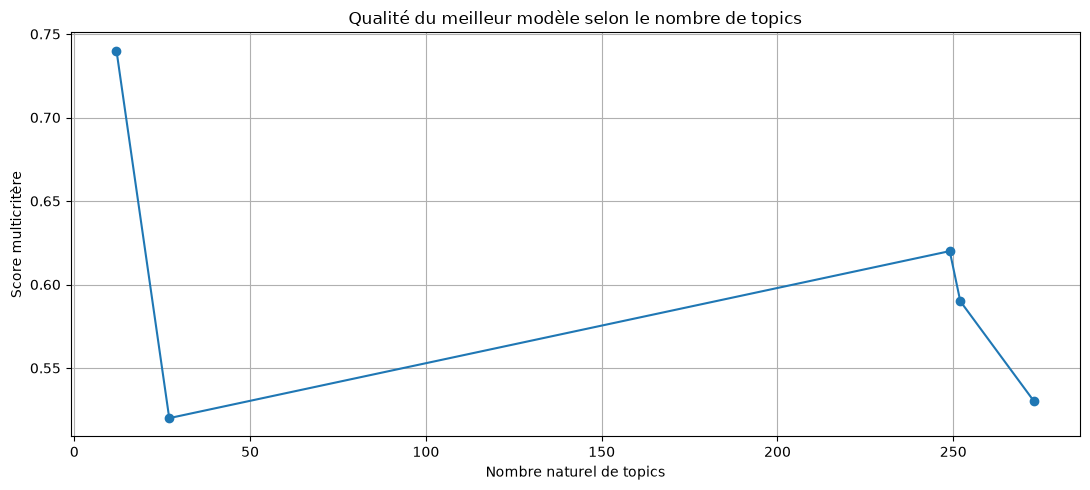

In [31]:
plt.figure(figsize=(11, 5))

plt.plot(
    meilleur_par_nombre_topics["n_topics"],
    meilleur_par_nombre_topics["score_global"],
    marker="o"
)
plt.xlabel("Nombre naturel de topics")
plt.ylabel("Score multicritère")
plt.title("Qualité du meilleur modèle selon le nombre de topics")

plt.grid(True)
plt.tight_layout()
plt.show()

## 5. Évaluation de la stabilité

Les meilleures configurations sont réentraînées avec plusieurs graines aléatoires afin de mesurer la stabilité des regroupements.

In [32]:
def entrainer_configuration(
    params,
    seed,
    documents,
    embeddings_array
):
    """
    Entraîne une configuration BERTopic avec une seed donnée.
    """

    umap_model = UMAP(
        n_neighbors=int(params["n_neighbors"]),
        n_components=int(params["n_components"]),
        min_dist=0.0,
        metric="cosine",
        random_state=int(seed),
        low_memory=True
    )

    hdbscan_model = HDBSCAN(
        min_cluster_size=int(params["min_cluster_size"]),
        min_samples=int(params["min_samples"]),
        metric="euclidean",
        cluster_selection_method="eom",
        prediction_data=False,
        core_dist_n_jobs=-1
    )

    vectorizer_model = CountVectorizer(
        min_df=2,
        max_df=0.8,
    )

    ctfidf_model = ClassTfidfTransformer(
        reduce_frequent_words=True,
        bm25_weighting=True
    )

    model = BERTopic(
        language="french",
        hdbscan_model=hdbscan_model,
        umap_model=umap_model,
        vectorizer_model=vectorizer_model,
        ctfidf_model=ctfidf_model,
        calculate_probabilities=False,
        nr_topics=None,
        verbose=False
    )

    topics, _ = model.fit_transform(documents, embeddings=embeddings_array)
    return model, np.asarray(topics)


def calculer_stabilite(listes_labels):
    """
    Compare plusieurs exécutions d'une même configuration.

    Deux mesures :
    - ARI sur tous les documents ;
    - ARI sur les documents assignés dans les deux exécutions.
    """

    ari_tous = []
    ari_assignes = []
    parts_communes = []

    for labels_a, labels_b in combinations(
        listes_labels,
        2
    ):

        labels_a = np.asarray(labels_a)
        labels_b = np.asarray(labels_b)

        # ARI comprenant le label -1
        ari_tous.append(
            adjusted_rand_score(
                labels_a,
                labels_b
            )
        )

        # Documents assignés dans les deux modèles
        masque_commun = (
            (labels_a != -1)
            & (labels_b != -1)
        )

        parts_communes.append(
            masque_commun.mean()
        )

        labels_a_communs = labels_a[masque_commun]
        labels_b_communs = labels_b[masque_commun]

        condition_ari = (
            len(labels_a_communs) >= 2
            and len(np.unique(labels_a_communs)) >= 2
            and len(np.unique(labels_b_communs)) >= 2
        )

        if condition_ari:

            ari_assignes.append(
                adjusted_rand_score(
                    labels_a_communs,
                    labels_b_communs
                )
            )

        else:

            ari_assignes.append(np.nan)

    return {
        "stability_ari_all_mean": np.nanmean(ari_tous),
        "stability_ari_all_std": np.nanstd(ari_tous),
        "stability_ari_assigned_mean": np.nanmean(
            ari_assignes
        ),
        "stability_ari_assigned_std": np.nanstd(
            ari_assignes
        ),
        "common_assigned_share": np.nanmean(
            parts_communes
        )
    }

In [33]:
N_MEILLEURS_MODELES = 10

SEEDS = [11, 30, 42, 57, 73]


top_configurations = (
    candidats
    .head(N_MEILLEURS_MODELES)
    .copy()
    .reset_index()
    .rename(columns={"index": "result_index"})
)


resultats_stabilite = []


for position, ligne in top_configurations.iterrows():

    params = {
        "n_neighbors": int(ligne["n_neighbors"]),
        "n_components": int(ligne["n_components"]),
        "min_cluster_size": int(
            ligne["min_cluster_size"]
        ),
        "min_samples": int(ligne["min_samples"])
    }

    print(
        f"\nConfiguration stable "
        f"{position + 1}/{len(top_configurations)}"
    )

    print(params)

    labels_par_seed = []
    nombres_topics = []
    taux_outliers = []

    for seed in SEEDS:

        print(f"  Seed {seed}")

        model_seed, labels_seed = (
            entrainer_configuration(
                params=params,
                seed=seed,
                documents=documents,
                embeddings_array=embeddings_array
            )
        )

        labels_par_seed.append(labels_seed)

        nombres_topics.append(
            len(
                np.unique(
                    labels_seed[labels_seed != -1]
                )
            )
        )

        taux_outliers.append(
            np.mean(labels_seed == -1)
        )

        del model_seed
        gc.collect()

    stabilite = calculer_stabilite(
        labels_par_seed
    )

    resultats_stabilite.append({
        "result_index": ligne["result_index"],
        **params,
        **stabilite,
        "mean_n_topics": np.mean(nombres_topics),
        "std_n_topics": np.std(nombres_topics),
        "mean_outlier_rate": np.mean(taux_outliers),
        "std_outlier_rate": np.std(taux_outliers)
    })


stabilite_df = pd.DataFrame(resultats_stabilite)

display(
    stabilite_df.style.format({
        "stability_ari_all_mean": "{:.3f}",
        "stability_ari_all_std": "{:.3f}",
        "stability_ari_assigned_mean": "{:.3f}",
        "stability_ari_assigned_std": "{:.3f}",
        "common_assigned_share": "{:.1%}",
        "mean_n_topics": "{:.1f}",
        "std_n_topics": "{:.2f}",
        "mean_outlier_rate": "{:.1%}",
        "std_outlier_rate": "{:.1%}"
    })
)




Configuration stable 1/5
{'n_neighbors': 60, 'n_components': 20, 'min_cluster_size': 120, 'min_samples': 1}
  Seed 11
  Seed 30
  Seed 42
  Seed 57
  Seed 73

Configuration stable 2/5
{'n_neighbors': 10, 'n_components': 10, 'min_cluster_size': 20, 'min_samples': 1}
  Seed 11
  Seed 30
  Seed 42
  Seed 57
  Seed 73

Configuration stable 3/5
{'n_neighbors': 10, 'n_components': 20, 'min_cluster_size': 20, 'min_samples': 1}
  Seed 11
  Seed 30
  Seed 42
  Seed 57
  Seed 73

Configuration stable 4/5
{'n_neighbors': 10, 'n_components': 15, 'min_cluster_size': 20, 'min_samples': 1}
  Seed 11
  Seed 30
  Seed 42
  Seed 57
  Seed 73

Configuration stable 5/5
{'n_neighbors': 10, 'n_components': 15, 'min_cluster_size': 120, 'min_samples': 1}
  Seed 11
  Seed 30
  Seed 42
  Seed 57
  Seed 73


,result_index,n_neighbors,n_components,min_cluster_size,min_samples,stability_ari_all_mean,stability_ari_all_std,stability_ari_assigned_mean,stability_ari_assigned_std,common_assigned_share,mean_n_topics,std_n_topics,mean_outlier_rate,std_outlier_rate
0,207,60,20,120,1,0.567,0.045,0.766,0.101,23.8%,17.2,0.75,68.1%,3.1%
1,4,10,10,20,1,0.183,0.155,0.495,0.290,33.0%,199.4,98.90,46.3%,22.9%
2,12,10,20,20,1,0.104,0.149,0.235,0.332,43.1%,148.0,119.31,35.2%,27.9%
3,8,10,15,20,1,0.186,0.162,0.406,0.334,32.4%,196.2,97.21,47.1%,22.9%
4,200,10,15,120,1,0.062,0.201,0.128,0.272,45.6%,10.4,10.37,37.6%,18.7%


In [34]:
top_configurations_stables = (
    top_configurations
    .merge(
        stabilite_df[
            [
                "result_index",
                "stability_ari_all_mean",
                "stability_ari_assigned_mean",
                "common_assigned_share",
                "mean_n_topics",
                "std_n_topics",
                "mean_outlier_rate"
            ]
        ],
        on="result_index",
        how="left"
    )
)


top_configurations_stables["stability_rank"] = (
    top_configurations_stables[
        "stability_ari_assigned_mean"
    ]
    .rank(pct=True)
    .fillna(0.5)
)


top_configurations_stables["score_final"] = (
    0.80
    * top_configurations_stables["score_global"]

    + 0.20
    * top_configurations_stables["stability_rank"]
)


top_configurations_stables = (top_configurations_stables.sort_values("score_final",ascending=False))


display(
    top_configurations_stables[
        [
            "n_neighbors",
            "n_components",
            "min_cluster_size",
            "min_samples",
            "n_topics",
            "outlier_rate",
            "coherence_cv",
            "silhouette_umap",
            "dbcv",
            "topic_diversity",
            "stability_ari_assigned_mean",
            "mean_n_topics",
            "std_n_topics",
            "score_global",
            "score_final"
        ]
    ]
    .style.format({
        "outlier_rate": "{:.1%}",
        "coherence_cv": "{:.3f}",
        "silhouette_umap": "{:.3f}",
        "dbcv": "{:.3f}",
        "topic_diversity": "{:.3f}",
        "stability_ari_assigned_mean": "{:.3f}",
        "mean_n_topics": "{:.1f}",
        "std_n_topics": "{:.2f}",
        "score_global": "{:.3f}",
        "score_final": "{:.3f}"
    })
)

,n_neighbors,n_components,min_cluster_size,min_samples,n_topics,outlier_rate,coherence_cv,silhouette_umap,dbcv,topic_diversity,stability_ari_assigned_mean,mean_n_topics,std_n_topics,score_global,score_final
0,60,20,120,1,12,59.3%,0.525,0.298,-0.076,0.958,0.766,17.2,0.75,0.740,0.792
1,10,10,20,1,249,57.6%,0.390,0.286,0.002,0.900,0.495,199.4,98.90,0.620,0.656
2,10,20,20,1,252,58.9%,0.388,0.293,0.043,0.898,0.235,148.0,119.31,0.590,0.552
3,10,15,20,1,273,56.9%,0.380,0.294,0.022,0.896,0.406,196.2,97.21,0.530,0.544
4,10,15,120,1,27,59.2%,0.495,0.220,-0.072,0.904,0.128,10.4,10.37,0.520,0.456


## 6. Choix du modèle retenu

Le modèle produisant 33 topics est retenu volontairement, car cette granularité paraît plus pertinente pour l'interprétation du corpus que la solution à 8 topics classée devant lui par le score automatique.

In [35]:
meilleure_ligne = top_configurations_stables.iloc[0]

# Même graine que pendant la grid search
SEED_FINALE = RANDOM_STATE  # 42

best_params = {
    "n_neighbors": int(meilleure_ligne["n_neighbors"]),
    "n_components": int(meilleure_ligne["n_components"]),
    "min_cluster_size": int(meilleure_ligne["min_cluster_size"]),
    "min_samples": int(meilleure_ligne["min_samples"]),
    "random_state": int(SEED_FINALE),
    "expected_n_topics": int(meilleure_ligne["n_topics"])
}

print("Meilleurs paramètres :")
print(best_params)

print(
    "\nGraine retenue :",
    best_params["random_state"]
)

print(
    "Nombre naturel de topics lors de la grille :",
    best_params["expected_n_topics"]
)

print(
    "Nombre moyen de topics sur plusieurs graines :",
    round(meilleure_ligne["mean_n_topics"], 1)
)

Meilleurs paramètres :
{'n_neighbors': 60, 'n_components': 20, 'min_cluster_size': 120, 'min_samples': 1, 'random_state': 42, 'expected_n_topics': 12}

Graine retenue : 42
Nombre naturel de topics lors de la grille : 12
Nombre moyen de topics sur plusieurs graines : 17.2


## 7. Export des résultats et des paramètres retenus

In [36]:
chemin_sortie = Path("..") /"data" /"3_optimisation" /"classement_modeles_bertopic.csv"
chemin_sortie.parent.mkdir(parents=True, exist_ok=True)
candidats.to_csv(chemin_sortie, index=False, encoding="utf-8")


chemin_sortie = Path("..") /"data" /"3_optimisation" /"stabilite_modeles_bertopic.csv"
chemin_sortie.parent.mkdir(parents=True, exist_ok=True)
stabilite_df.to_csv(chemin_sortie, index=False, encoding="utf-8")

dossier = Path("../data/donnees_annex")
dossier.mkdir(parents=True, exist_ok=True)
fichier = dossier / "meilleurs_parametres_bertopic.json"
with fichier.open("w", encoding="utf-8") as f:
    json.dump(best_params, f, indent=2, ensure_ascii=False)
    print(fichier.resolve())





/Users/morganrichard/zola-dtm/data/donnees_annex/meilleurs_parametres_bertopic.json
